In [1]:
# ============================================================================
# CELL 1 — IMPORTS / CONFIG  (replaces the original imports cell)
# ============================================================================
import warnings

warnings.filterwarnings("ignore")

import os, math, json, copy, random
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import mlflow
import mlflow.pytorch
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from data_loading import *
from loss_funcs import *

# ---- reproducibility ----
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")
    torch.backends.cudnn.benchmark = True
    print("float32 matmul precision = 'medium', cudnn.benchmark = True")

PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision = 'medium', cudnn.benchmark = True


In [2]:
weather_cols_all = ['temperature_2m',
       'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m',
       'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low',
       'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure',
       'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance']

other_cols = [ # these are not static
    'dam_price', 'buy_bm_price', 'sell_bm_price',
    'max_power', 'max_solar', 'max_ev'
]

cat_columns = [
    'eic_code', 'dso_desc', 'station_type', 'oblast',
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

static_cols = [
    'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast'
]

calendar_cols = [
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

time_cols = ['datetime', 'time_idx']

FUTURE_REALS = weather_cols_all + calendar_cols + static_cols + other_cols
print(f"y col is: {Y_COL}, group col is: {GROUP_COL}\n"
      f"features: {FUTURE_REALS}")

y col is: sum_of_kWh, group col is: eic_code
features: ['temperature_2m', 'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance', 'Month', 'Day', 'Hour', 'day_of_week', 'season', 'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast', 'dam_price', 'buy_bm_price', 'sell_bm_price', 'max_power', 'max_solar', 'max_ev']


In [3]:
# this data has a data column and categorical columns are kept intact and will need to be handled.
# "time_idx" is already built in train, val and test and is continuous through them
print("Loading train …")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)

print("Loading val   …")
val = load_and_prepare(VAL_PATH_WITH_DATETME)

print("Loading test  …")
test = load_and_prepare(TEST_PATH_WITH_DATETME)

print(f"train: {train.shape}")
print(f"val : {val.shape}")
print(f"test: {test.shape}")

Loading train …
Loading val   …
Loading test  …
train: (4586151, 38)
val : (293880, 38)
test: (295430, 38)


In [4]:
# ============================================================================
# CELL 3 — ROSE HYPERPARAMETERS
# ----------------------------------------------------------------------------
# ROSE is a channel-independent patch transformer with:
#   - RevIN instance normalization
#   - Patch tokenization of the lookback window
#   - A learnable Register codebook; top-K register tokens are prepended to
#     the patch sequence to inject domain-specific information
#   - Transformer encoder
#   - Linear flatten head producing the full forecast horizon
#
# We forecast sum_of_kWh per (eic_code, time) pair. Station identity is
# carried implicitly via RevIN (each window is normalized by its own stats)
# and explicitly via the register tokens which the model learns to retrieve
# per series.
# ============================================================================
MAX_EPOCHS = 30

ROSE_CFG = dict(
    # Window sizing (hourly data → 7-day lookback, 2-day forecast)
    seq_len      = 168,
    pred_len     = 48,
    patch_len    = 16,
    patch_stride = 8,
    # Transformer
    d_model      = 128,
    n_heads      = 8,
    n_layers     = 3,
    d_ff         = 256,
    dropout      = 0.1,
    # Register
    register_size = 64,   # codebook size
    register_topk = 4,    # tokens prepended per sample
    # Channels: target + numeric covariates that ROSE will see as
    # channel-independent inputs. Categorical fields are excluded here
    # (ROSE is univariate per-channel; we surface station identity through
    # RevIN + register selection, not as a channel).
    use_covariates = True,
    # Training
    batch_size  = 256,
    epochs      = MAX_EPOCHS,
    lr          = 1e-3,
    weight_decay= 1e-4,
    grad_clip   = 1.0,
    # Loss blending — money_pct can be unstable early; warm up with MAE
    loss_money_weight = 1.0,
    loss_mae_weight   = 0.1,
    # Stride between training windows (sliding window step)
    train_stride = 24,
    val_stride   = 24,
)

# Numeric covariate channels (everything in FUTURE_REALS that's truly numeric).
# Static categoricals like eic_code/dso_desc/oblast are dropped here — they
# don't vary in time so they aren't useful as additional channels.
NUMERIC_COVARIATES = [
    *weather_cols_all,
    "dam_price", "buy_bm_price", "sell_bm_price",
    "max_power", "max_solar", "max_ev",
    # cyclic-ish calendar features used as numeric channels
    "Hour", "day_of_week", "Month",
]
# Keep only those that actually exist in train (defensive)
NUMERIC_COVARIATES = [c for c in NUMERIC_COVARIATES if c in train.columns]

# Price columns are also needed by money loss; we keep their raw values aside
PRICE_COLS = ["dam_price", "sell_bm_price", "buy_bm_price"]

print(f"Lookback : {ROSE_CFG['seq_len']}h   Horizon : {ROSE_CFG['pred_len']}h")
print(f"Channels : 1 target + {len(NUMERIC_COVARIATES)} covariates"
      f" = {1 + len(NUMERIC_COVARIATES)}")

Lookback : 168h   Horizon : 48h
Channels : 1 target + 27 covariates = 28


In [5]:
# ============================================================================
# CELL 4 — DATASET: per-station sliding windows with prices preserved
# ----------------------------------------------------------------------------
# We build (lookback, horizon) windows per eic_code. The dataset returns:
#   x         : [C, L]    target + covariates as channels (channel-independent)
#   y         : [pred_len] target ground truth
#   prices    : [pred_len, 3]  dam_price, sell_bm_price, buy_bm_price
#                              (needed for the money loss)
#   t_idx     : scalar absolute time_idx of the first forecast step
#   group_id  : integer station id (used to map to register selection later
#               for analysis, not required by ROSE itself which retrieves
#               registers from content)
# ============================================================================

class ROSEWindowDataset(Dataset):
    def __init__(self, df: pd.DataFrame, target_col: str, group_col: str,
                 covariate_cols: List[str], price_cols: List[str],
                 seq_len: int, pred_len: int, stride: int,
                 group_to_id: Dict, feature_means: Dict, feature_stds: Dict):
        self.target_col = target_col
        self.group_col  = group_col
        self.cov_cols   = covariate_cols
        self.price_cols = price_cols
        self.seq_len    = seq_len
        self.pred_len   = pred_len
        self.group_to_id = group_to_id

        # Standardize covariates globally (target is RevIN-normalized later).
        # We keep the price columns un-standardized because money loss must
        # see real currency-denominated prices.
        self.feature_means = feature_means
        self.feature_stds  = feature_stds

        # Build window indices: list of (group_key, group_df_view, start_idx)
        self.index = []                 # list of tuples for __getitem__
        self._cache = {}                # group_key -> stacked numpy arrays

        for grp, gdf in df.sort_values([group_col, "time_idx"]).groupby(group_col):
            n = len(gdf)
            if n < seq_len + pred_len:
                continue

            tgt = gdf[target_col].to_numpy(dtype=np.float32)
            cov = gdf[covariate_cols].to_numpy(dtype=np.float32)
            # Standardize covariates
            cov = (cov - self.feature_means) / self.feature_stds
            prc = gdf[price_cols].to_numpy(dtype=np.float32)
            tix = gdf["time_idx"].to_numpy(dtype=np.int64)

            self._cache[grp] = (tgt, cov, prc, tix)

            last_start = n - seq_len - pred_len
            for s in range(0, last_start + 1, stride):
                self.index.append((grp, s))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        grp, s = self.index[i]
        tgt, cov, prc, tix = self._cache[grp]
        L, H = self.seq_len, self.pred_len

        x_tgt = tgt[s : s + L]                         # [L]
        x_cov = cov[s : s + L]                         # [L, C-1]
        # Stack target + covariates as channels: [C, L]
        x = np.concatenate([x_tgt[None, :], x_cov.T], axis=0)

        y       = tgt[s + L : s + L + H]               # [H]
        prices  = prc[s + L : s + L + H]               # [H, 3]
        t_start = tix[s + L]
        gid     = self.group_to_id.get(grp, -1)

        return (
            torch.from_numpy(x),                        # [C, L] float32
            torch.from_numpy(y),                        # [H]
            torch.from_numpy(prices),                   # [H, 3]
            torch.tensor(t_start, dtype=torch.long),
            torch.tensor(gid, dtype=torch.long),
        )


# ---- Compute covariate normalization stats on TRAIN only -------------------
_train_cov = train[NUMERIC_COVARIATES].to_numpy(dtype=np.float32)
FEAT_MEAN  = _train_cov.mean(axis=0)
FEAT_STD   = _train_cov.std(axis=0) + 1e-6
del _train_cov

# ---- Build group_to_id map (every station seen anywhere) -------------------
all_groups = sorted(set(train[GROUP_COL].unique())
                    | set(val[GROUP_COL].unique())
                    | set(test[GROUP_COL].unique()))
GROUP_TO_ID = {g: i for i, g in enumerate(all_groups)}
N_GROUPS = len(GROUP_TO_ID)

# ---- For val/test we glue the lookback context onto the front so we can
#      forecast from time_idx = val.start onwards. The training notebook
#      states val/test/train share a continuous time_idx, so we stitch.
def _stitch_context(prev_df: pd.DataFrame, target_df: pd.DataFrame,
                    seq_len: int) -> pd.DataFrame:
    """Prepend `seq_len` rows of context per group from prev_df onto target_df."""
    pieces = []
    for grp, gdf in target_df.groupby(GROUP_COL):
        ctx = prev_df[prev_df[GROUP_COL] == grp].tail(seq_len)
        pieces.append(pd.concat([ctx, gdf], axis=0))
    return pd.concat(pieces, axis=0).sort_values([GROUP_COL, "time_idx"]) \
                                    .reset_index(drop=True)

val_with_ctx  = _stitch_context(train, val,  ROSE_CFG["seq_len"])
test_with_ctx = _stitch_context(val,   test, ROSE_CFG["seq_len"])

# ---- Build the three datasets ----------------------------------------------
common_kwargs = dict(
    target_col=Y_COL, group_col=GROUP_COL,
    covariate_cols=NUMERIC_COVARIATES, price_cols=PRICE_COLS,
    seq_len=ROSE_CFG["seq_len"], pred_len=ROSE_CFG["pred_len"],
    group_to_id=GROUP_TO_ID, feature_means=FEAT_MEAN, feature_stds=FEAT_STD,
)
train_ds = ROSEWindowDataset(train,         stride=ROSE_CFG["train_stride"], **common_kwargs)
val_ds   = ROSEWindowDataset(val_with_ctx,  stride=ROSE_CFG["val_stride"],   **common_kwargs)
test_ds  = ROSEWindowDataset(test_with_ctx, stride=ROSE_CFG["pred_len"],     **common_kwargs)
# test stride = pred_len ⇒ non-overlapping forecast tiles covering the full month

print(f"Train windows: {len(train_ds):,}")
print(f"Val   windows: {len(val_ds):,}")
print(f"Test  windows: {len(test_ds):,}")

NUM_WORKERS = 4
train_loader = DataLoader(train_ds, batch_size=ROSE_CFG["batch_size"],
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=ROSE_CFG["batch_size"],
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=ROSE_CFG["batch_size"],
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

Train windows: 187,601
Val   windows: 11,850
Test  windows: 5,925


In [6]:
# ============================================================================
# CELL 5 — DIFFERENTIABLE MONEY LOSS (PyTorch wrapper)
# ----------------------------------------------------------------------------
# Faithful PyTorch reimplementation of money_pct() from loss_funcs.py.
#
# Numpy reference:
#     diff = y_pred - y_true
#     real_spend = y_pred*price
#                  - where(diff>0, selling_price*diff, 0)   # sell excess back
#                  - where(diff<0, buying_price *diff, 0)   # buy shortfall
#                                                            # (diff<0 → adds cost)
#     money_pct  = sum(real_spend - y_true*price) / (sum(y_true*price)/100)
#     prices are divided by 1000 internally
#
# This is piecewise linear in y_pred, so it's already differentiable
# everywhere except at diff=0 (a measure-zero point) — no sigmoid smoothing
# needed.  We use the same `relu` decomposition that numpy's `where` gives:
#     max(y_pred - y_true, 0) * sell  +  max(y_true - y_pred, 0) * buy
# both terms are subgradient-friendly.
# ============================================================================

class MoneyLoss(nn.Module):
    """Differentiable money loss matching loss_funcs.money_pct().

    Inputs (all same shape, e.g. [B, H]):
        y_true, y_pred, dam, sell, buy   (raw prices, not /1000)
    Modes:
        'pct' — matches money_pct() exactly: percentage of ideal spend
        'abs' — matches money()    exactly: absolute extra spend
    """
    def __init__(self, mode: str = "pct"):
        super().__init__()
        assert mode in ("abs", "pct")
        self.mode = mode

    def forward(self, y_true, y_pred, dam, sell, buy):
        # Match the /1000 done inside money_pct
        dam  = dam  / 1000.0
        sell = sell / 1000.0
        buy  = buy  / 1000.0

        diff = y_pred - y_true
        # diff > 0: over-prediction → sells excess at `sell`  (refund)
        # diff < 0: under-prediction → buys shortfall at `buy` (extra cost)
        over  = F.relu( diff)            # = max(diff, 0)
        under = F.relu(-diff)            # = max(-diff, 0)

        ordered    = y_pred * dam
        min_spend  = y_true * dam
        # real_spend = ordered  -  sell*over  +  buy*under
        # (numpy form: ordered - where(diff>0, sell*diff, 0) - where(diff<0, buy*diff, 0)
        #   the second `where` has diff<0, so buy*diff is negative, and the
        #   minus sign makes the cost positive ⇒ same as +buy*under)
        real_spend = ordered - sell * over + buy * under
        extra      = real_spend - min_spend

        if self.mode == "pct":
            # money_pct = sum(extra) / (sum(min_spend)/100)
            #          = 100 * sum(extra) / sum(min_spend)
            return 100.0 * extra.sum() / (min_spend.sum().clamp_min(1e-8))
        return extra.sum()


# ---- Sanity check vs numpy reference --------------------------------------
with torch.no_grad():
    yt = torch.tensor([10.0, 10.0, 10.0, 10.0])
    yp = torch.tensor([10.0, 11.5, 8.5, 10.05])   # exact, over, under, near
    p  = torch.tensor([5000., 5000., 5000., 5000.])  # raw prices (will be /1000 internally)
    s  = torch.tensor([3000., 3000., 3000., 3000.])
    b  = torch.tensor([7000., 7000., 7000., 7000.])

    soft_pct = MoneyLoss(mode="pct")(yt, yp, p, s, b).item()
    soft_abs = MoneyLoss(mode="abs")(yt, yp, p, s, b).item()
    hard_pct = money_pct(yt.numpy(), yp.numpy(), p.numpy(), s.numpy(), b.numpy())
    hard_abs = money    (yt.numpy(), yp.numpy(), p.numpy(), s.numpy(), b.numpy())

    print(f"Sanity — pct  surrogate: {soft_pct:.6f}   numpy: {hard_pct:.6f}")
    print(f"Sanity — abs  surrogate: {soft_abs:.6f}   numpy: {hard_abs:.6f}")

Sanity — pct  surrogate: 3.049999   numpy: 3.050000
Sanity — abs  surrogate: 6.099998   numpy: 6.100000


In [7]:
# ============================================================================
# CELL 6 — ROSE MODEL
# ----------------------------------------------------------------------------
# Faithful (compact) reimplementation of ROSE for fine-tuning:
#
#   1. RevIN per-channel instance normalization on the lookback.
#   2. Patch the lookback into overlapping patches of length `patch_len`
#      with stride `patch_stride`  (PatchTST-style, channel-independent).
#   3. Linear-embed each patch → patch tokens [B*C, N_patches, d_model]
#      + positional embedding.
#   4. TS-Register: a learnable codebook of `register_size` tokens. For each
#      sample (channel-independent), produce a query from the mean patch
#      embedding; pick top-K registers by cosine similarity; concatenate
#      them in front of the patch tokens.
#   5. Transformer encoder on the full (register + patch) sequence.
#   6. Drop the register positions, flatten patch tokens, linear head →
#      forecast of length pred_len for every channel.
#   7. RevIN denormalize. We only return the target channel's forecast.
# ============================================================================

class RevIN(nn.Module):
    """Reversible per-channel instance normalization (Kim et al., 2021)."""
    def __init__(self, num_channels: int, eps: float = 1e-5, affine: bool = True):
        super().__init__()
        self.eps = eps
        self.affine = affine
        if affine:
            self.weight = nn.Parameter(torch.ones(num_channels))
            self.bias   = nn.Parameter(torch.zeros(num_channels))

    def normalize(self, x):
        # x: [B, C, L]
        self.mean = x.mean(dim=-1, keepdim=True).detach()
        self.std  = x.std(dim=-1, keepdim=True).detach() + self.eps
        x = (x - self.mean) / self.std
        if self.affine:
            x = x * self.weight.view(1, -1, 1) + self.bias.view(1, -1, 1)
        return x

    def denormalize(self, x):
        # x: [B, C, H]
        if self.affine:
            x = (x - self.bias.view(1, -1, 1)) / (self.weight.view(1, -1, 1) + self.eps)
        return x * self.std + self.mean


class TSRegister(nn.Module):
    """ROSE's Time-Series Register: a learnable codebook + top-K retrieval.

    During training the codebook is updated by gradient descent. For each
    (sample × channel), we compute a query from the patch-token mean and
    retrieve the top-K most similar register vectors, which are then
    prepended to the patch sequence as extra tokens.
    """
    def __init__(self, register_size: int, d_model: int, topk: int):
        super().__init__()
        self.codebook = nn.Parameter(torch.randn(register_size, d_model) * 0.02)
        self.topk = topk
        self.q_proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, patch_tokens):
        # patch_tokens: [B*C, N, d_model]
        q = self.q_proj(patch_tokens.mean(dim=1))                 # [B*C, d_model]
        cb = F.normalize(self.codebook, dim=-1)                   # [R, d_model]
        qn = F.normalize(q, dim=-1)                               # [B*C, d_model]
        sim = qn @ cb.T                                           # [B*C, R]
        topk_sim, topk_idx = sim.topk(self.topk, dim=-1)          # [B*C, K]
        # Soft-weighted sum  is one option, but ROSE uses the actual selected
        # tokens as a sequence. We gather them and weight by softmax(sim).
        weights = F.softmax(topk_sim, dim=-1).unsqueeze(-1)       # [B*C, K, 1]
        selected = self.codebook[topk_idx]                        # [B*C, K, d_model]
        return selected * weights                                 # [B*C, K, d_model]


class ROSE(nn.Module):
    def __init__(self, n_channels: int, seq_len: int, pred_len: int,
                 patch_len: int, patch_stride: int,
                 d_model: int, n_heads: int, n_layers: int, d_ff: int,
                 dropout: float, register_size: int, register_topk: int,
                 target_channel_idx: int = 0):
        super().__init__()
        self.n_channels   = n_channels
        self.seq_len      = seq_len
        self.pred_len     = pred_len
        self.patch_len    = patch_len
        self.patch_stride = patch_stride
        self.target_idx   = target_channel_idx

        # Number of patches after unfolding
        self.n_patches = (seq_len - patch_len) // patch_stride + 1

        self.revin = RevIN(n_channels)
        self.patch_embed = nn.Linear(patch_len, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)
        self.register    = TSRegister(register_size, d_model, register_topk)
        self.reg_pos     = nn.Parameter(torch.randn(1, register_topk, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head_dropout = nn.Dropout(dropout)
        self.head = nn.Linear(self.n_patches * d_model, pred_len)

    def forward(self, x):
        # x: [B, C, L]
        B, C, L = x.shape
        x = self.revin.normalize(x)

        # Channel-independent: fold C into batch
        x_ci = x.reshape(B * C, L)
        # Patch via unfold: [B*C, N, patch_len]
        patches = x_ci.unfold(-1, self.patch_len, self.patch_stride)
        tokens  = self.patch_embed(patches) + self.pos_embed       # [B*C, N, d]

        # Register tokens prepended
        reg_tokens = self.register(tokens) + self.reg_pos          # [B*C, K, d]
        seq = torch.cat([reg_tokens, tokens], dim=1)               # [B*C, K+N, d]

        seq = self.encoder(seq)
        # Drop register positions, keep patch tokens
        patch_out = seq[:, reg_tokens.size(1):, :]                 # [B*C, N, d]
        flat = patch_out.reshape(B * C, -1)
        flat = self.head_dropout(flat)
        y = self.head(flat)                                        # [B*C, H]

        y = y.reshape(B, C, self.pred_len)
        y = self.revin.denormalize(y)                              # [B, C, H]
        return y[:, self.target_idx, :]                            # [B, H]


N_CHANNELS = 1 + len(NUMERIC_COVARIATES)
model = ROSE(
    n_channels   = N_CHANNELS,
    seq_len      = ROSE_CFG["seq_len"],
    pred_len     = ROSE_CFG["pred_len"],
    patch_len    = ROSE_CFG["patch_len"],
    patch_stride = ROSE_CFG["patch_stride"],
    d_model      = ROSE_CFG["d_model"],
    n_heads      = ROSE_CFG["n_heads"],
    n_layers     = ROSE_CFG["n_layers"],
    d_ff         = ROSE_CFG["d_ff"],
    dropout      = ROSE_CFG["dropout"],
    register_size= ROSE_CFG["register_size"],
    register_topk= ROSE_CFG["register_topk"],
    target_channel_idx = 0,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ROSE parameters: {n_params/1e6:.2f}M")
print(model)

ROSE parameters: 0.55M
ROSE(
  (revin): RevIN()
  (patch_embed): Linear(in_features=16, out_features=128, bias=True)
  (register): TSRegister(
    (q_proj): Linear(in_features=128, out_features=128, bias=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head_dropout): Dropout(p=0.1, inplace=False)
  (head): Linear(in_features=256

In [8]:
# ============================================================================
# CELL 7 — TRAINING LOOP
# ============================================================================

from tqdm.auto import tqdm

# ---- Rebuild loaders with num_workers=0 ------------------------------------
# The dataset holds a big in-memory _cache dict. With num_workers>0, every
# worker fork-pickles that whole cache at DataLoader iter start, which can
# stall for minutes with ~zero CPU/GPU usage. Single-process loading is
# actually faster here because the data is already in RAM as numpy arrays.
train_loader = DataLoader(train_ds, batch_size=ROSE_CFG["batch_size"],
                          shuffle=True,  num_workers=0,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=ROSE_CFG["batch_size"],
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=ROSE_CFG["batch_size"],
                          shuffle=False, num_workers=0, pin_memory=True)

# ---- Sanity probe: confirm data + model work end-to-end before the loop ----
print("Sanity probe …", flush=True)
_x, _y, _p, _, _ = next(iter(train_loader))
print(f"  batch shapes: x={tuple(_x.shape)}  y={tuple(_y.shape)}  prices={tuple(_p.shape)}", flush=True)
with torch.no_grad():
    _yp = model(_x.to(DEVICE))
print(f"  forward ok  : yp={tuple(_yp.shape)}", flush=True)
del _x, _y, _p, _yp


def collect_metrics(y_true, y_pred, dam, sell, buy) -> Dict[str, float]:
    return dict(
        mae       = float(np.mean(np.abs(y_pred - y_true))),
        rmse      = float(rmse(y_true, y_pred)),
        mape      = float(mape(y_true, y_pred)),
        smape     = float(smape(y_true, y_pred)),
        money     = float(money(y_true, y_pred, dam, sell, buy)),
        money_pct = float(money_pct(y_true, y_pred, dam, sell, buy)),
        bias      = float(y_pred.sum() - y_true.sum()),
    )


@torch.no_grad()
def evaluate(model, loader, money_loss_fn):
    model.eval()
    ys, yps, prs, losses = [], [], [], []
    for x, y, prices, _, _ in loader:
        x, y, prices = x.to(DEVICE), y.to(DEVICE), prices.to(DEVICE)
        yp = model(x)
        dam, sell, buy = prices[..., 0], prices[..., 1], prices[..., 2]
        losses.append(money_loss_fn(y, yp, dam, sell, buy).item())
        ys.append(y.cpu().numpy()); yps.append(yp.cpu().numpy()); prs.append(prices.cpu().numpy())
    y_arr  = np.concatenate(ys ).reshape(-1)
    yp_arr = np.concatenate(yps).reshape(-1)
    pr_arr = np.concatenate(prs).reshape(-1, 3)
    m = collect_metrics(y_arr, yp_arr, pr_arr[:, 0], pr_arr[:, 1], pr_arr[:, 2])
    m["loss"] = float(np.mean(losses))
    return m, y_arr, yp_arr, pr_arr


# ---- MLflow setup ----------------------------------------------------------
mlflow.set_experiment(f"electricity_forecasting_rose_{MAX_EPOCHS}_epochs")
run = mlflow.start_run(run_name=f"ROSE_seq{ROSE_CFG['seq_len']}_h{ROSE_CFG['pred_len']}")

mlflow.log_params({**ROSE_CFG,
                   "n_channels": N_CHANNELS,
                   "n_stations": N_GROUPS,
                   "n_train_windows": len(train_ds),
                   "n_val_windows":   len(val_ds),
                   "n_test_windows":  len(test_ds),
                   "device": str(DEVICE),
                   "params_M": round(n_params/1e6, 3)})
mlflow.log_param("numeric_covariates", ",".join(NUMERIC_COVARIATES))
mlflow.log_param("train_date_range", f"{train['datetime'].min()} → {train['datetime'].max()}")
mlflow.log_param("val_date_range",   f"{val['datetime'].min()} → {val['datetime'].max()}")
mlflow.log_param("test_date_range",  f"{test['datetime'].min()} → {test['datetime'].max()}")

# ---- Optimizer / scheduler / loss -----------------------------------------
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=ROSE_CFG["lr"],
                              weight_decay=ROSE_CFG["weight_decay"])
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=ROSE_CFG["lr"],
    steps_per_epoch=len(train_loader), epochs=ROSE_CFG["epochs"],
    pct_start=0.1, anneal_strategy="cos",
)
money_loss      = MoneyLoss(mode="abs").to(DEVICE)   # train on absolute money
money_loss_pct  = MoneyLoss(mode="pct").to(DEVICE)   # for logging only
mae_loss        = nn.L1Loss()

best_val_money_pct = float("inf")
best_state = None
ckpt_path = "../models/rose/rose_best.pt"

print(f"Starting training: {ROSE_CFG['epochs']} epochs × {len(train_loader)} batches", flush=True)

for epoch in tqdm(range(1, ROSE_CFG["epochs"] + 1), desc="Epochs"):
    model.train()
    running_loss, running_money = 0.0, 0.0
    batch_bar = tqdm(train_loader, leave=False, desc=f"Epoch {epoch}")
    for x, y, prices, _, _ in batch_bar:
        x      = x.to(DEVICE, non_blocking=True)
        y      = y.to(DEVICE, non_blocking=True)
        prices = prices.to(DEVICE, non_blocking=True)
        dam, sell, buy = prices[..., 0], prices[..., 1], prices[..., 2]

        yp = model(x)
        if not torch.isfinite(yp).all():
            raise RuntimeError(f"NaN/Inf in predictions at epoch {epoch}, "
                               f"batch loss-so-far={running_loss:.4f}")

        m_loss = money_loss(y, yp, dam, sell, buy)        # abs, well-scaled
        mae_l  = mae_loss(yp, y)
        loss   = (ROSE_CFG["loss_money_weight"] * m_loss
                + ROSE_CFG["loss_mae_weight"]   * mae_l)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), ROSE_CFG["grad_clip"])
        optimizer.step()
        scheduler.step()

        running_loss  += loss.item()
        running_money += m_loss.item()
        batch_bar.set_postfix(loss=f"{loss.item():.4f}", money=f"{m_loss.item():.4f}")

    train_loss  = running_loss  / max(1, len(train_loader))
    train_money = running_money / max(1, len(train_loader))

    val_metrics, *_ = evaluate(model, val_loader, money_loss)
    print(f"epoch {epoch:02d} | train={train_loss:.4f} | "
          f"val_money={val_metrics['money']:.4f} "
          f"val_pct={val_metrics['money_pct']:.2f}% "
          f"val_mae={val_metrics['mae']:.3f}", flush=True)

    mlflow.log_metrics({
        "train_loss":  train_loss,
        "train_money": train_money,
        "lr":          optimizer.param_groups[0]["lr"],
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }, step=epoch)

    if val_metrics["money_pct"] < best_val_money_pct:
        best_val_money_pct = val_metrics["money_pct"]
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, ckpt_path)
        mlflow.log_metric("best_val_money_pct", best_val_money_pct, step=epoch)

if best_state is not None:
    model.load_state_dict(best_state)
print(f"Best val money_pct: {best_val_money_pct:.4f}")

Sanity probe …
  batch shapes: x=(256, 28, 168)  y=(256, 48)  prices=(256, 48, 3)
  forward ok  : yp=(256, 48)


2026/04/26 02:16:21 INFO mlflow.tracking.fluent: Experiment with name 'electricity_forecasting_rose_30_epochs' does not exist. Creating a new experiment.


Starting training: 30 epochs × 732 batches


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/732 [00:00<?, ?it/s]

...

epoch 28 | train=-2871175.7694 | val_money=3215644.0785 val_pct=5.67% val_mae=3.145


Epoch 29:   0%|          | 0/732 [00:00<?, ?it/s]

epoch 29 | train=-3059997.8101 | val_money=3235855.5638 val_pct=5.71% val_mae=3.175


Epoch 30:   0%|          | 0/732 [00:00<?, ?it/s]

epoch 30 | train=-3103543.5925 | val_money=3233563.9067 val_pct=5.70% val_mae=3.171
Best val money_pct: 4.8479


In [9]:
# ============================================================================
# CELL 8 — INFERENCE (build val_eval / test_eval frames)
# ----------------------------------------------------------------------------
# The test set spans roughly a month at hourly resolution. ROSE forecasts
# `pred_len` (=48h) per call; the test loader uses stride = pred_len and
# stitches the validation tail as initial context, so non-overlapping
# horizons tile the full month with no recursion needed.
#
# If you want to evaluate at a finer stride (e.g. every 24h with overlapping
# windows) just change ROSE_CFG['val_stride'] / dataset stride and re-build
# the loader; we then take the *latest* prediction per (group, time_idx)
# below to deduplicate.
# ============================================================================

@torch.no_grad()
def predict_to_frame(model, dataset: ROSEWindowDataset, source_df: pd.DataFrame,
                     loader: DataLoader) -> pd.DataFrame:
    """Run model on `loader` and join predictions back to `source_df` by
       (group, time_idx, datetime).  Returns frame with columns:
       [GROUP_COL, time_idx, datetime, Y_COL, pred, dam_price, sell_bm_price, buy_bm_price].
    """
    model.eval()
    rows = []
    # We need to recover (group, time_idx) per output step. Walk the dataset's
    # index list deterministically and re-batch.
    pred_chunks = []
    for x, y, prices, t_start, gid in tqdm(loader, desc="Predicting", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        yp = model(x).cpu().numpy()        # [B, H]
        pred_chunks.append(yp)
    preds = np.concatenate(pred_chunks, axis=0)   # [n_windows, H]

    # Walk dataset.index in the SAME order as the (non-shuffled) loader produced
    # → DataLoader without shuffle preserves dataset order.
    H = dataset.pred_len
    inv_id = {v: k for k, v in dataset.group_to_id.items()}  # not strictly needed
    for w_idx, (grp, s) in enumerate(dataset.index):
        tgt, cov, prc, tix = dataset._cache[grp]
        forecast_t = tix[s + dataset.seq_len : s + dataset.seq_len + H]
        true_y     = tgt[s + dataset.seq_len : s + dataset.seq_len + H]
        rows.append(pd.DataFrame({
            GROUP_COL: grp,
            "time_idx": forecast_t,
            Y_COL: true_y,
            "pred": preds[w_idx],
        }))
    pred_df = pd.concat(rows, ignore_index=True)
    # If multiple windows predicted the same (group, time_idx), keep the latest
    pred_df = pred_df.drop_duplicates(subset=[GROUP_COL, "time_idx"], keep="last")

    # Bring datetime + prices in from the source frame
    join_cols = [GROUP_COL, "time_idx", "datetime", *PRICE_COLS]
    eval_df = pred_df.merge(source_df[join_cols],
                            on=[GROUP_COL, "time_idx"], how="left")
    return eval_df.sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)


val_eval  = predict_to_frame(model, val_ds,  val,  val_loader)
test_eval = predict_to_frame(model, test_ds, test, test_loader)

print(f"val_eval : {val_eval.shape}, NaNs={val_eval.isna().any().any()}")
print(f"test_eval: {test_eval.shape}, NaNs={test_eval.isna().any().any()}")

Predicting:   0%|          | 0/47 [00:00<?, ?it/s]

Predicting:   0%|          | 0/24 [00:00<?, ?it/s]

val_eval : (293880, 8), NaNs=False
test_eval: (284400, 8), NaNs=False


In [10]:
# ============================================================================
# CELL 9 — FINAL METRICS + MLflow logging  (replaces the original eval cell)
# ============================================================================
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

def report(df, split):
    yt, yp = df[Y_COL].values, df["pred"].values
    dam, sell, buy = _prices(df)
    m = collect_metrics(yt, yp, dam, sell, buy)
    print(f"── {split} ──────────────────────────────────────────────")
    print(f"Aligned samples : {len(df):,}")
    print(f"MAE       : {m['mae']:.4f}")
    print(f"RMSE      : {m['rmse']:.4f}")
    print(f"MAPE      : {m['mape']:.2f} %")
    print(f"SMAPE     : {m['smape']:.4f}")
    print(f"MONEY     : {m['money']:.4f}")
    print(f"MONEY_PCT : {m['money_pct']:.4f}%")
    print(f"BIAS      : {m['bias']:+.2f}  (pred_sum - actual_sum)")
    return m

val_m  = report(val_eval,  "Validation")
test_m = report(test_eval, "Test")

mlflow.log_metrics({**{f"val_{k}":  v for k, v in val_m.items()},
                    **{f"test_{k}": v for k, v in test_m.items()}})

# Log artifacts
mlflow.log_artifact(ckpt_path)
val_eval.to_parquet("val_eval.parquet");  mlflow.log_artifact("val_eval.parquet")
test_eval.to_parquet("test_eval.parquet"); mlflow.log_artifact("test_eval.parquet")
mlflow.pytorch.log_model(model, "rose_model")

print(f"MLflow run logged → {mlflow.get_tracking_uri()}")

── Validation ──────────────────────────────────────────────
Aligned samples : 293,880
MAE       : 2.9556
RMSE      : 7.2280
MAPE      : 17.36 %
SMAPE     : 0.1568
MONEY     : 1359621.5099
MONEY_PCT : 4.6507%
BIAS      : -320841.00  (pred_sum - actual_sum)
── Test ──────────────────────────────────────────────
Aligned samples : 284,400
MAE       : 2.9299
RMSE      : 7.9926
MAPE      : 17.73 %
SMAPE     : 0.1496
MONEY     : 1482736.1602
MONEY_PCT : 5.2060%
BIAS      : -190520.00  (pred_sum - actual_sum)


2026/04/26 03:06:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/26 03:06:38 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/26 03:06:47 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/26 03:06:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example`

MLflow run logged → file:///C:/Users/Lev/Documents/GitHub/Diploma/train_models_v2/mlruns


In [11]:
val_eval

,eic_code,time_idx,sum_of_kWh,pred,datetime,dam_price,sell_bm_price,buy_bm_price
0,62Z0008583037334,13126,21.000000,19.231165,2025-07-01 00:00:00+03:00,5568.520020,0.01,5846.950195
1,62Z0008583037334,13127,19.000000,16.501175,2025-07-01 01:00:00+03:00,5568.419922,0.01,5846.839844
2,62Z0008583037334,13128,16.000000,14.651911,2025-07-01 02:00:00+03:00,5190.000000,0.01,5449.500000
3,62Z0008583037334,13129,16.000000,13.009632,2025-07-01 03:00:00+03:00,4888.000000,0.01,5132.399902
4,62Z0008583037334,13130,15.000000,12.853248,2025-07-01 04:00:00+03:00,4299.000000,0.01,4513.950195
...,...,...,...,...,...,...,...,...
293875,62Z9997819406173,13863,22.759968,22.819691,2025-07-31 19:00:00+03:00,8700.000000,4.52,9135.000000
293876,62Z9997819406173,13864,22.367891,21.684290,2025-07-31 20:00:00+03:00,8896.230469,4.59,9341.040039
293877,62Z9997819406173,13865,22.995213,23.677910,2025-07-31 21:00:00+03:00,9000.000000,8550.00,10499.940430
293878,62Z9997819406173,13866,23.455900,21.759598,2025-07-31 22:00:00+03:00,8860.000000,8417.00,10499.929688


In [12]:
# ============================================================================
# CELL 10 — PER-STATION METRICS (fixed: real money/money_pct, not duplicated MAPE)
# ============================================================================
def per_station_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for grp, gdf in eval_df.groupby(GROUP_COL):
        dam, sell, buy = _prices(gdf)
        rows.append({
            GROUP_COL:   grp,
            "n":         len(gdf),
            "MAE":       float(np.mean(np.abs(gdf["pred"] - gdf[Y_COL]))),
            "RMSE":      rmse (gdf[Y_COL], gdf["pred"]),
            "MAPE":      mape (gdf[Y_COL], gdf["pred"]),
            "SMAPE":     smape(gdf[Y_COL], gdf["pred"]),
            "MONEY":     money    (gdf[Y_COL], gdf["pred"], dam, sell, buy),
            "MONEY_PCT": money_pct(gdf[Y_COL], gdf["pred"], dam, sell, buy),
        })
    return pd.DataFrame(rows).sort_values("MONEY_PCT")

test_station_metrics = per_station_metrics(test_eval)
print("Top-10 best stations (test MONEY_PCT):")
print(test_station_metrics.head(10).to_string(index=False))
print("\nBottom-10 worst stations (test MONEY_PCT):")
print(test_station_metrics.tail(10).to_string(index=False))

test_station_metrics.to_csv("test_station_metrics.csv", index=False)
mlflow.log_artifact("test_station_metrics.csv")

Top-10 best stations (test MONEY_PCT):
        eic_code   n      MAE     RMSE     MAPE    SMAPE       MONEY  MONEY_PCT
62Z6969613150684 720 1.962131 2.458610 5.202639 0.053048 1992.403357   1.378314
62Z2673921373211 720 2.550522 3.159351 5.289024 0.053555 2691.890717   1.455072
62Z9572466865833 720 3.653090 4.564488 5.334398 0.054453 3822.993485   1.457342
62Z9191598698031 720 3.394711 4.202689 5.327927 0.053884 3621.526207   1.481791
62Z4026142936382 720 1.906748 2.360275 5.369455 0.054243 2052.859107   1.507068
62Z0011230718431 720 0.544576 0.723610 4.869363 0.048573  764.706814   1.786196
62Z0259886906816 720 0.931141 1.171583 6.152366 0.064183 1059.535678   1.816880
62Z0271773349182 720 1.717767 2.082448 6.814051 0.071213 1814.111005   1.848283
62Z0232888687220 720 0.061576 0.075323 6.216079 0.064713   72.809229   1.915693
62Z0211989286227 720 1.394792 1.721109 5.915514 0.060626 1926.901536   2.154436

Bottom-10 worst stations (test MONEY_PCT):
        eic_code   n       MAE      R

Best  station (MONEY_PCT): 62Z6969613150684


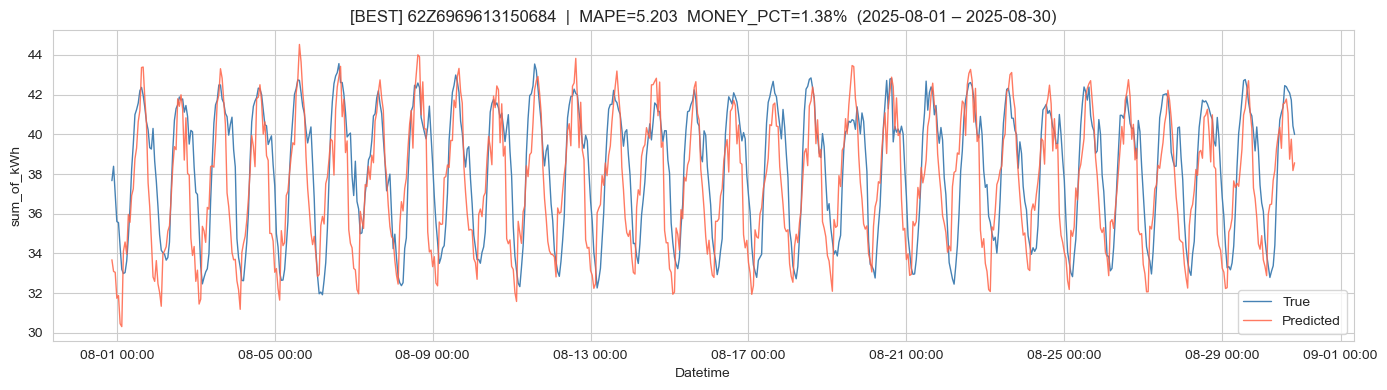

Worst station (MONEY_PCT): 62Z6035944504754


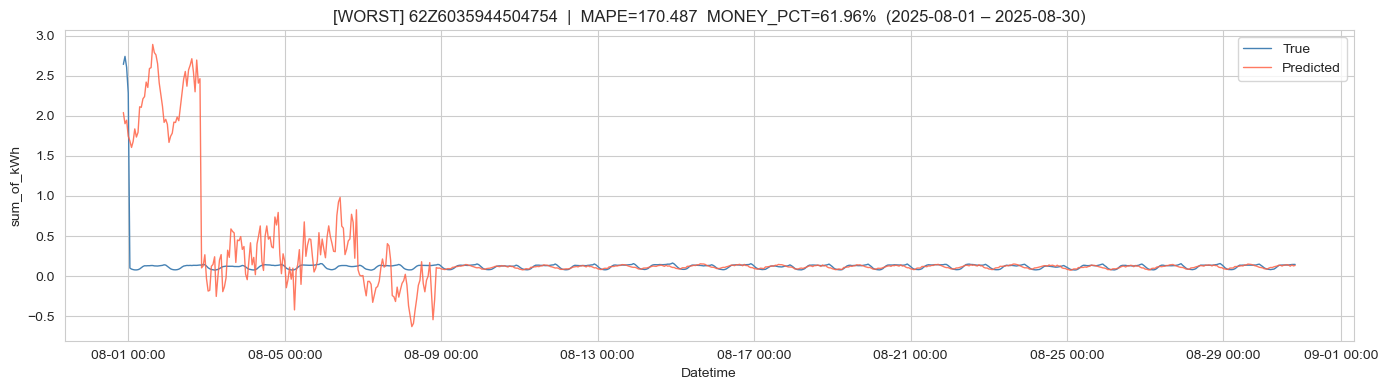

Done.


In [13]:
# ============================================================================
# CELL 11 — PLOTS  (your existing plot_forecast utility — unchanged)
# ============================================================================
def plot_forecast(df, eic_code, start_dt=None, end_dt=None, title_prefix=""):
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty: raise ValueError(f"No data for EiC code: {eic_code!r}")
    if start_dt is not None: df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt   is not None: df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty: raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{title_prefix}{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  MONEY_PCT={money_pct(df[Y_COL], df['pred'], *_prices(df)):.2f}%"
        f"  ({df['datetime'].min().date()} – {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime"); ax.set_ylabel(Y_COL); ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center"); plt.tight_layout()
    fname = f"forecast_{title_prefix.strip().strip('[]').lower() or 'plot'}_{eic_code}.png"
    plt.savefig(fname, dpi=110, bbox_inches="tight")
    mlflow.log_artifact(fname)
    plt.show()

best_station  = test_station_metrics.iloc[0][GROUP_COL]
worst_station = test_station_metrics.iloc[-1][GROUP_COL]
print(f"Best  station (MONEY_PCT): {best_station}")
plot_forecast(test_eval, eic_code=best_station,  title_prefix="[BEST] ")
print(f"Worst station (MONEY_PCT): {worst_station}")
plot_forecast(test_eval, eic_code=worst_station, title_prefix="[WORST] ")

mlflow.end_run()
print("Done.")